## Imports

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import modules.visualization.timeseries_plot as tsp

In [3]:
from modules.visualization.bar_plots import (
    plot_transactions_by_cash_type,
    plot_payment_value_by_cash_type
)


In [4]:
%load_ext autoreload
%autoreload 2

## Load dataset

In [5]:
import pandas as pd
from pathlib import Path

data_path = Path("../exploration/data/coffee_sales_prepared.parquet")

df = pd.read_parquet(data_path)
df.head()

,date,datetime,cash_type,card,money,coffee_name,hour,day_of_week,day_of_week_num,month,year,is_weekend,season
0,2024-03-01,2024-03-01 10:15:50.520,card,anon-0000-0000-0001,38.7,latte,10,Friday,4,3,2024,False,spring
1,2024-03-01,2024-03-01 12:19:22.539,card,anon-0000-0000-0002,38.7,hot chocolate,12,Friday,4,3,2024,False,spring
2,2024-03-01,2024-03-01 12:20:18.089,card,anon-0000-0000-0002,38.7,hot chocolate,12,Friday,4,3,2024,False,spring
3,2024-03-01,2024-03-01 13:46:33.006,card,anon-0000-0000-0003,28.9,americano,13,Friday,4,3,2024,False,spring
4,2024-03-01,2024-03-01 13:48:14.626,card,anon-0000-0000-0004,38.7,latte,13,Friday,4,3,2024,False,spring


## Daily time range

In [11]:
daily_time_range = (
    df.groupby("date")
    .agg(
        first_sale_time=("datetime", "min"),
        last_sale_time=("datetime", "max"),
        total_transactions=("datetime", "count")
    )
    .reset_index()
)

daily_time_range["first_sale_hour"] = daily_time_range["first_sale_time"].dt.hour
daily_time_range["last_sale_hour"] = daily_time_range["last_sale_time"].dt.hour

daily_time_range.head()

,date,first_sale_time,last_sale_time,total_transactions,first_sale_hour,last_sale_hour
0,2024-03-01,2024-03-01 10:15:50.520,2024-03-01 19:29:17.391,11,10,19
1,2024-03-02,2024-03-02 10:22:06.957,2024-03-02 17:34:54.969,7,10,17
2,2024-03-03,2024-03-03 10:10:43.981,2024-03-03 18:08:04.959,10,10,18
3,2024-03-04,2024-03-04 10:03:51.994,2024-03-04 14:04:37.734,4,10,14
4,2024-03-05,2024-03-05 09:59:52.651,2024-03-05 18:01:31.242,9,9,18


In [12]:
daily_time_range[["first_sale_hour", "last_sale_hour"]].mode()

,first_sale_hour,last_sale_hour
0,8,21


## Total revenue by week

In [61]:
sales_by_weekday = (
    df.groupby(["day_of_week_num", "day_of_week"])
      .agg(total_revenue=("money", "sum"))
      .reset_index()
      .sort_values("day_of_week_num")
)

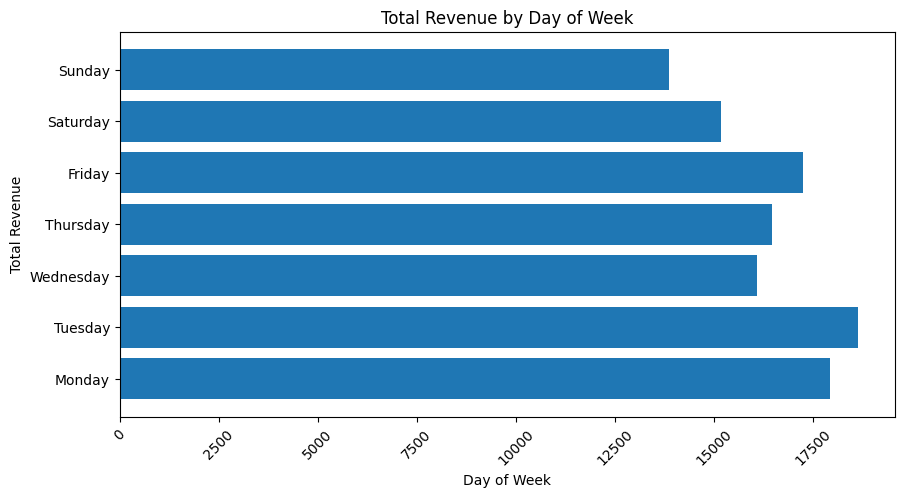

In [62]:
plt.figure(figsize=(10, 5))
plt.barh(sales_by_weekday["day_of_week"], sales_by_weekday["total_revenue"])
plt.title("Total Revenue by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.show()

## Total revenue by day

In [63]:
hourly_demand = (
    df.groupby("hour")
      .agg(
          total_transactions=("money", "count"),
          total_revenue=("money", "sum")
      )
      .reset_index()
)

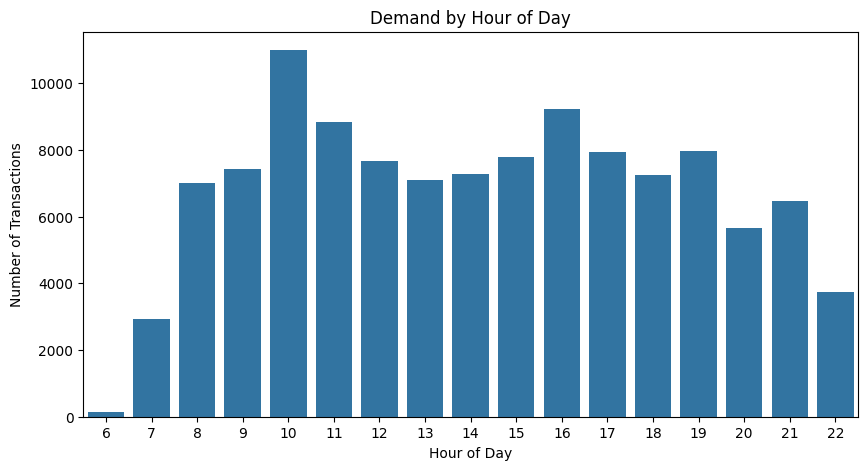

In [64]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=hourly_demand,
    x="hour",
    y="total_revenue"
)

plt.title("Demand by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Transactions")
plt.show()

## Coffe sales x seasons

Como coffe_name e season são variaveis categóricas, o mais apropriado é realizar uma analise por associação. Assim, pode-se observar a distribuição percentual de vandas por tipo de bebida em cada estação do ano. Utilizando um heatmap, um insight interessante é que em todas as estações do ano, as bebidas a base de leite representam a maior participação nas vendas. Isso pode ser importante no cenário em oferecer mix de produtos por estação e possíveis campanhas sazonais.

Insights adicionais possíveis:
- Produto âncora: se bebidas com leite lideram em todas as estações, elas podem ser tratadas como produtos principais do portfólio. O negócio deve evitar ruptura desses itens.
- Campanhas sazonais: se algum café aumenta participação em uma estação específica, ele pode ser usado em campanhas temporárias, combos ou destaque na comunicação da máquina.
- Gestão de estoque: a sazonalidade do mix ajuda a planejar reposição por tipo de bebida, não apenas volume total de vendas.

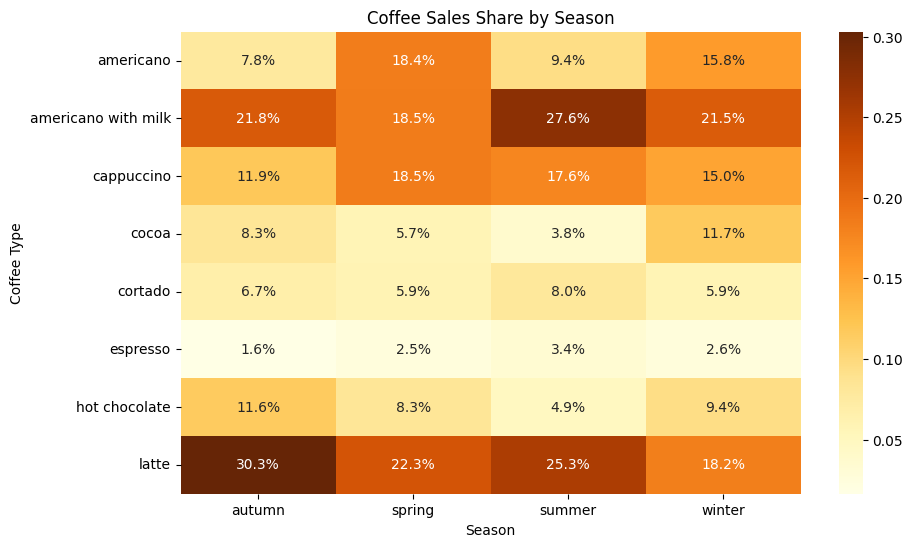

In [65]:
coffee_season = pd.crosstab(
    df["coffee_name"],
    df["season"],
    values=df["money"],
    aggfunc="sum",
    normalize="columns"
)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.heatmap(coffee_season, annot=True, fmt=".1%", cmap="YlOrBr")

plt.title("Coffee Sales Share by Season")
plt.xlabel("Season")
plt.ylabel("Coffee Type")
plt.show()

In [98]:
df.columns

Index(['date', 'datetime', 'cash_type', 'card', 'money', 'coffee_name', 'hour',
       'day_of_week', 'day_of_week_num', 'month', 'year', 'is_weekend',
       'season'],
      dtype='object')

## Daily revenue over time

In [66]:
daily_sales = (
    df.groupby("date")
      .agg(
          total_revenue=("money", "sum"),
          total_transactions=("money", "count")
      )
      .reset_index()
      .sort_values("date")
)

In [67]:
df.columns

Index(['date', 'datetime', 'cash_type', 'card', 'money', 'coffee_name', 'hour',
       'day_of_week', 'day_of_week_num', 'month', 'year', 'is_weekend',
       'season'],
      dtype='object')

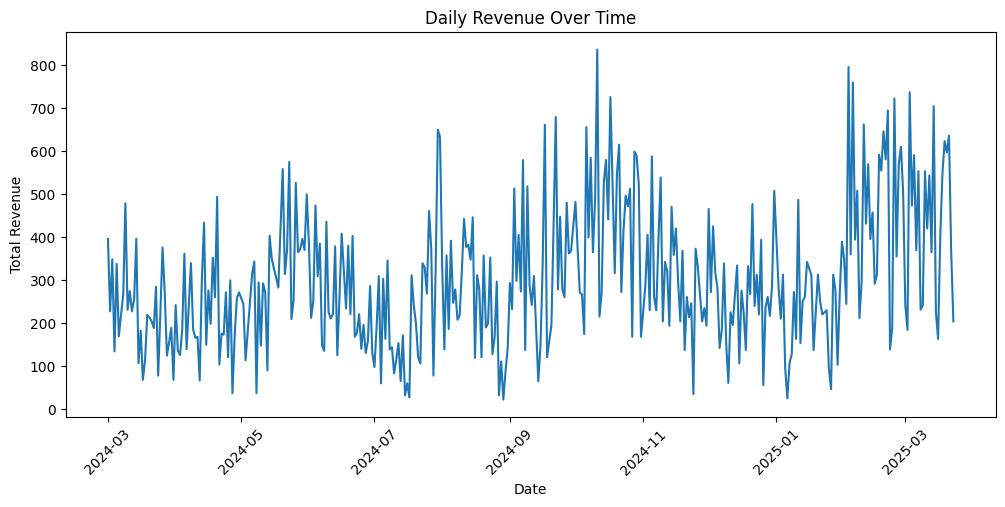

In [69]:
plt.figure(figsize=(12, 5))
plt.plot(daily_sales["date"], daily_sales["total_revenue"])

plt.title("Daily Revenue Over Time")
plt.xlabel("Date")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.show()

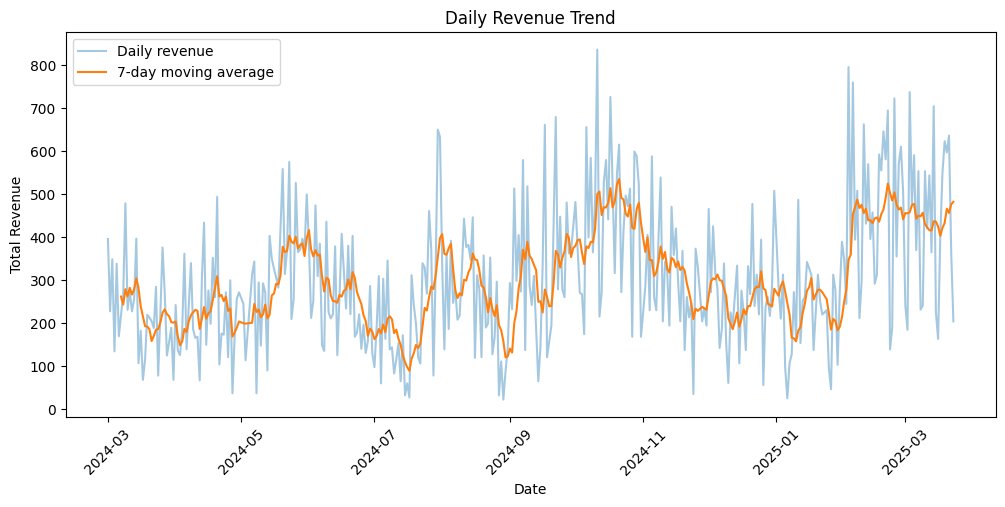

In [70]:
daily_sales["revenue_7d_avg"] = daily_sales["total_revenue"].rolling(7).mean()

plt.figure(figsize=(12, 5))
plt.plot(daily_sales["date"], daily_sales["total_revenue"], alpha=0.4, label="Daily revenue")
plt.plot(daily_sales["date"], daily_sales["revenue_7d_avg"], label="7-day moving average")

plt.title("Daily Revenue Trend")
plt.xlabel("Date")
plt.ylabel("Total Revenue")
plt.legend()
plt.xticks(rotation=45)
plt.show()

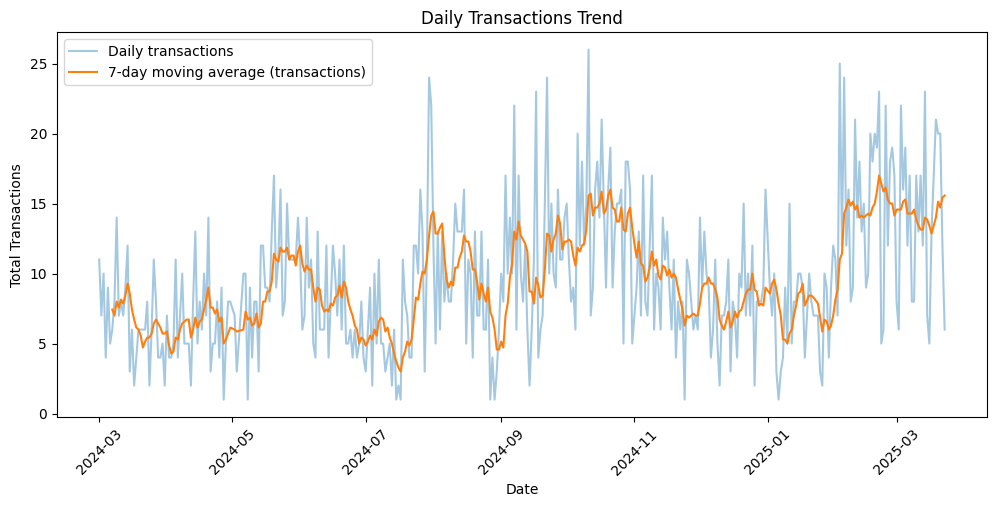

In [71]:
daily_sales["transactions_7d_avg"] = daily_sales["total_transactions"].rolling(7).mean()

plt.figure(figsize=(12, 5))
plt.plot(daily_sales["date"], daily_sales["total_transactions"], alpha=0.4, label="Daily transactions")
plt.plot(daily_sales["date"], daily_sales["transactions_7d_avg"], label="7-day moving average (transactions)")

plt.title("Daily Transactions Trend")
plt.xlabel("Date")
plt.ylabel("Total Transactions")
plt.legend()
plt.xticks(rotation=45)
plt.show()

In [72]:
monthly_sales = (
    df.groupby(pd.Grouper(key="date", freq="M"))
      .agg(total_revenue=("money", "sum"))
      .reset_index()
)

monthly_sales["year"] = monthly_sales["date"].dt.year
monthly_sales["month"] = monthly_sales["date"].dt.month

monthly_sales[monthly_sales["month"] == 3]

C:\Users\carolina.bezerra\AppData\Local\Temp\ipykernel_45992\4270278754.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df.groupby(pd.Grouper(key="date", freq="M"))


,date,total_revenue,year,month
0,2024-03-31,7050.20,2024,3
12,2025-03-31,9986.44,2025,3


Comparando março de 2025 com março de 2024, a receita total aumentou de 7.050,20 para 9.986,44, representando um crescimento de aproximadamente 41,65%. Esse resultado reforça a tendência de crescimento observada na média móvel de 7 dias e sugere aumento da demanda ao longo do tempo.

In [74]:
march_sales = monthly_sales[monthly_sales["month"] == 3]
march_sales = march_sales.sort_values("date")
march_sales["growth_pct"] = march_sales["total_revenue"].pct_change() * 100

march_sales

,date,total_revenue,year,month,growth_pct
0,2024-03-31,7050.20,2024,3,NaN
12,2025-03-31,9986.44,2025,3,41.647613


In [75]:
daily_sales_by_type = (
    df.groupby(["date", "coffee_name"])
      .agg(
          total_revenue=("money", "sum"),
          total_transactions=("money", "count")
      )
      .reset_index()
      .sort_values("date")
)

In [76]:
daily_sales_by_type.head(5)

,date,coffee_name,total_revenue,total_transactions
0,2024-03-01,americano,28.9,1
1,2024-03-01,americano with milk,135.2,4
2,2024-03-01,cocoa,38.7,1
3,2024-03-01,hot chocolate,116.1,3
4,2024-03-01,latte,77.4,2


## Daily revenue by coffe type

In [77]:
top_coffees = (
    df["coffee_name"]
    .value_counts()
    .head(3)
    .index
)

df_top = df[df["coffee_name"].isin(top_coffees)]

In [78]:
top_coffees

Index(['americano with milk', 'latte', 'americano'], dtype='string', name='coffee_name')

In [86]:
daily_coffee_sales = (
    df_top.groupby(["date", "coffee_name"])
    .agg(total_revenue=("money", "sum"))
    .reset_index()
)

In [89]:
daily_coffee_sales['revenue_7d_avg'] = daily_coffee_sales.groupby("coffee_name")["total_revenue"].transform(lambda x: x.rolling(7).mean())

Em alguns períodos, a liderança entre os cafés mais vendidos se inverte. Ao adicionar as estações do ano como contexto visual, é possível investigar se essas mudanças estão associadas a variações sazonais de preferência, como maior demanda por bebidas mais cremosas ou com leite em períodos frios.

In [81]:
daily_coffee_sales = (
    df_top.groupby(["date", "coffee_name"])
    .agg(total_transactions=("coffee_name", "count"))
    .reset_index()
)

In [91]:
daily_coffee_sales["transactions_7d_avg"] = (
    df_top.groupby(["date", "coffee_name"])
        .agg(total_transactions=("coffee_name", "count"))
        .reset_index()
    .groupby("coffee_name")["total_transactions"]
    .transform(lambda x: x.rolling(7).mean())
)

In [94]:
daily_coffee_sales["revenue_7d_avg"] = (
    df_top.groupby(["date", "coffee_name"])
        .agg(total_revenue=("money", "sum"))
        .reset_index()
    .groupby("coffee_name")["total_revenue"]
    .transform(lambda x: x.rolling(7).mean())
)

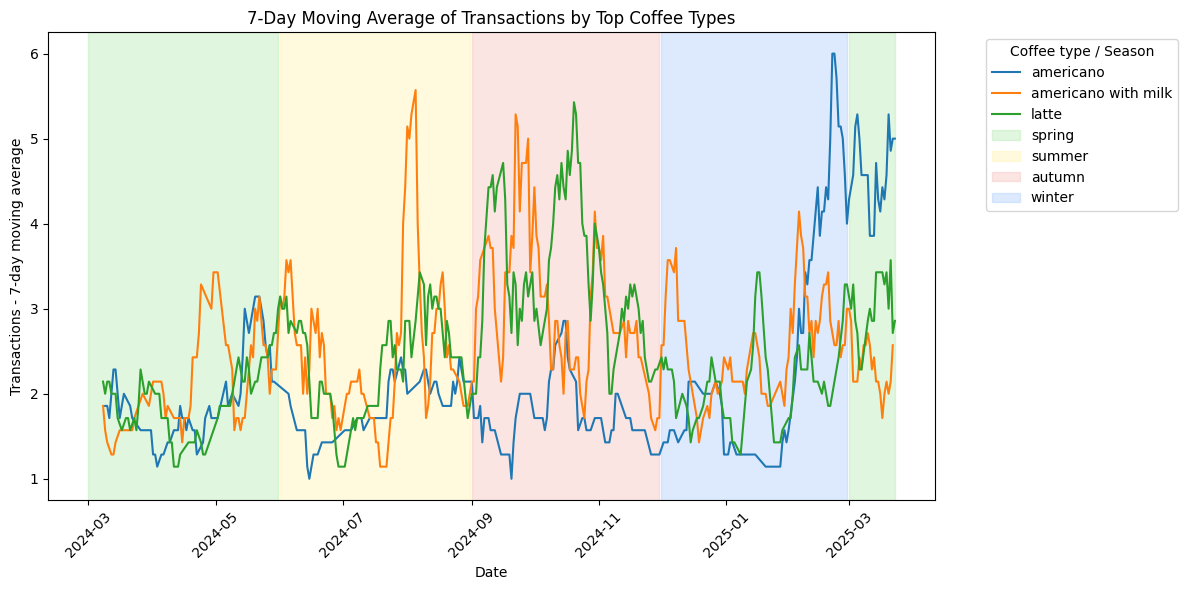

In [96]:
tsp.plot_coffee_trend_with_seasons(
    sales_df=daily_coffee_sales,
    season_df=df
)

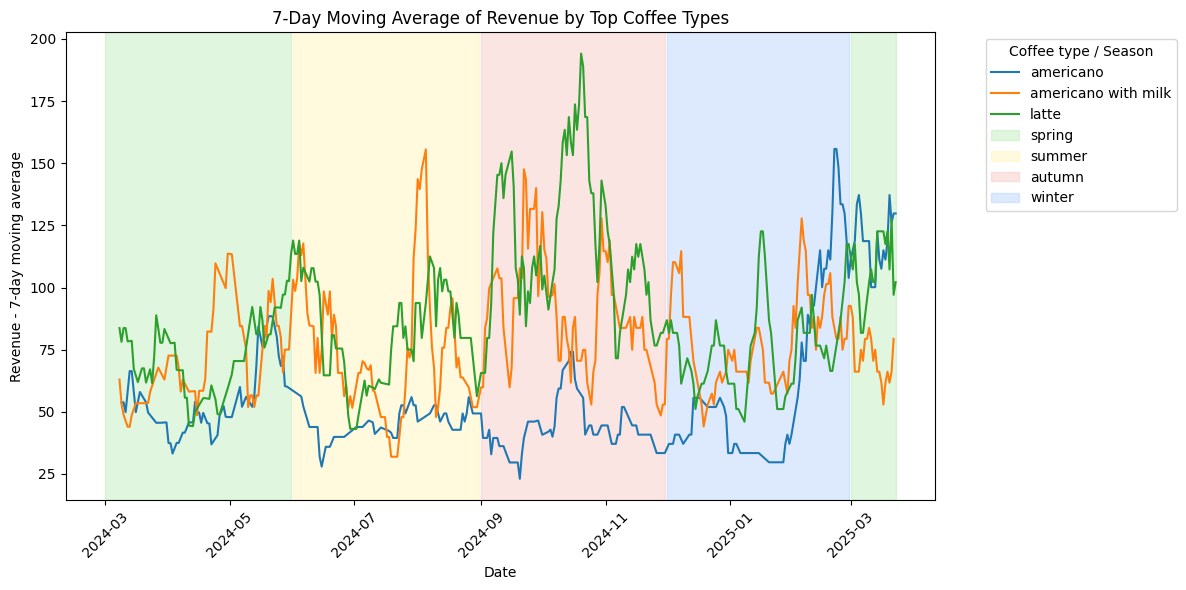

In [97]:
tsp.plot_coffee_trend_with_seasons(
    sales_df=daily_coffee_sales,
    season_df=df,
    value_col="revenue_7d_avg",
    title="7-Day Moving Average of Revenue by Top Coffee Types",
    ylabel="Revenue - 7-day moving average"
)

## Costumers

c:\Users\carolina.bezerra\Documents\My_Repo_Github\coffe_sales_repo\modules\visualization\bar_plots.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


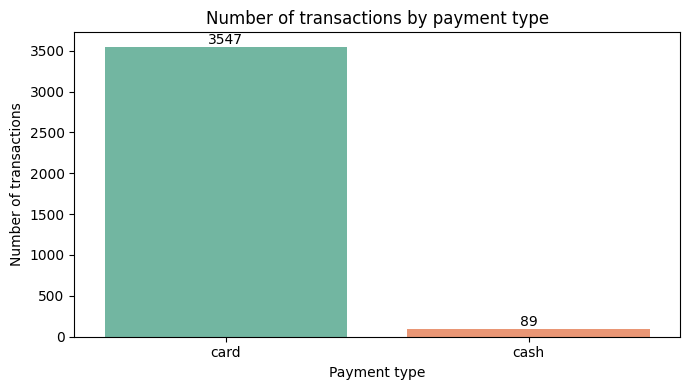

In [6]:
plot_transactions_by_cash_type(df)

In [8]:
df.head(5)

,date,datetime,cash_type,card,money,coffee_name,hour,day_of_week,day_of_week_num,month,year,is_weekend,season
0,2024-03-01,2024-03-01 10:15:50.520,card,anon-0000-0000-0001,38.7,latte,10,Friday,4,3,2024,False,spring
1,2024-03-01,2024-03-01 12:19:22.539,card,anon-0000-0000-0002,38.7,hot chocolate,12,Friday,4,3,2024,False,spring
2,2024-03-01,2024-03-01 12:20:18.089,card,anon-0000-0000-0002,38.7,hot chocolate,12,Friday,4,3,2024,False,spring
3,2024-03-01,2024-03-01 13:46:33.006,card,anon-0000-0000-0003,28.9,americano,13,Friday,4,3,2024,False,spring
4,2024-03-01,2024-03-01 13:48:14.626,card,anon-0000-0000-0004,38.7,latte,13,Friday,4,3,2024,False,spring


In [9]:
df.columns

Index(['date', 'datetime', 'cash_type', 'card', 'money', 'coffee_name', 'hour',
       'day_of_week', 'day_of_week_num', 'month', 'year', 'is_weekend',
       'season'],
      dtype='object')

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3636 entries, 0 to 3635
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   date             3636 non-null   datetime64[ns]
 1   datetime         3636 non-null   datetime64[ns]
 2   cash_type        3636 non-null   string        
 3   card             3547 non-null   string        
 4   money            3636 non-null   float64       
 5   coffee_name      3636 non-null   string        
 6   hour             3636 non-null   int32         
 7   day_of_week      3636 non-null   object        
 8   day_of_week_num  3636 non-null   int32         
 9   month            3636 non-null   int32         
 10  year             3636 non-null   int32         
 11  is_weekend       3636 non-null   bool          
 12  season           3636 non-null   object        
dtypes: bool(1), datetime64[ns](2), float64(1), int32(4), object(2), string(3)
memory usage: 287.7

c:\Users\carolina.bezerra\Documents\My_Repo_Github\coffe_sales_repo\modules\visualization\bar_plots.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


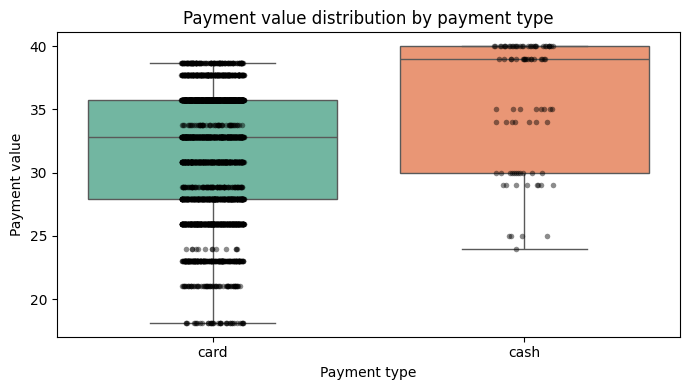

In [7]:
plot_payment_value_by_cash_type(df)